In [ ]:
# pip install matplotlib seaborn xgboost lightgbm

In [ ]:
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, RandomForestClassifier ,GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeRegressor , DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np

In [ ]:
import pandas as pd
import random

# Load your dataset
df = pd.read_csv("lane_cost_corrected_v3(in).csv")

# Define axle type columns
axle_columns = ['axle_3', 'axle_4', 'axle_5', 'axle_6_plus']

# Initialize all axle columns with 0
for col in axle_columns:
    df[col] = 0

# Randomly assign exactly ONE axle type per row
for i in range(len(df)):
    chosen_axle = random.choice(axle_columns)
    df.loc[i, chosen_axle] = 1

# Save updated dataset
df.to_csv("lane_cost_corrected_v3_with_single_axle.csv", index=False)

print("✅ Added one axle type per row successfully!")
print(df[axle_columns].head(10))


✅ Added one axle type per row successfully!
   axle_3  axle_4  axle_5  axle_6_plus
0       1       0       0            0
1       0       0       0            1
2       0       0       0            1
3       1       0       0            0
4       0       1       0            0
5       0       0       1            0
6       1       0       0            0
7       0       1       0            0
8       0       0       1            0
9       0       1       0            0


In [ ]:
df = pd.read_csv("lane_cost_corrected_v3_with_single_axle.csv")
# Add 'shipment_id' column at position 0 (inplace)
df.insert(0, 'shipment_id', [f"SH_{i:03}" for i in range(1, len(df) + 1)])
df.head()

,shipment_id,origin_city,destination_city,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,traffic_status,road_condition_score,weather_condition,...,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,avg_speed_mph_corrected,axle_3,axle_4,axle_5,axle_6_plus
0,SH_001,"Chicago, IL","Dallas, TX",63.2,12.8,4.04,6.19,Medium,5.1,Rain,...,925,70,2007.25,603.715670,2610.965670,63.2,1,0,0,0
1,SH_002,"Seattle, WA","Chicago, IL",72.4,23.2,3.65,6.28,Medium,7.1,Clear,...,1993,80,5444.88,1158.351911,6603.231911,72.4,0,0,0,1
2,SH_003,"Atlanta, GA","Seattle, WA",69.0,13.9,3.56,6.17,Low,4.8,Storm,...,2505,70,5398.28,1445.348460,6843.628460,69.0,0,0,0,1
3,SH_004,"Phoenix, AZ","Houston, TX",47.0,5.1,4.63,6.83,Low,8.4,Fog,...,1166,60,2123.29,790.421669,2913.711669,47.0,1,0,0,0
4,SH_005,"Atlanta, GA","Miami, FL",44.1,26.6,4.25,5.32,Low,4.4,Fog,...,697,60,1288.06,556.813910,1844.873910,44.1,0,1,0,0


In [ ]:
df.shape

(3000, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                3000 non-null   object 
 1   origin_city                3000 non-null   object 
 2   destination_city           3000 non-null   object 
 3   avg_speed_mph              3000 non-null   float64
 4   weight_of_truck_tons       3000 non-null   float64
 5   fuel_price_usd_per_gallon  3000 non-null   float64
 6   fuel_efficiency_mpg        3000 non-null   float64
 7   traffic_status             3000 non-null   object 
 8   road_condition_score       3000 non-null   float64
 9   weather_condition          3000 non-null   object 
 10  season                     3000 non-null   object 
 11  delivery_target_days       3000 non-null   int64  
 12  driver_hours_per_day       3000 non-null   int64  
 13  market_demand_index        3000 non-null   float

In [ ]:
df.isnull().sum()

shipment_id                  0
origin_city                  0
destination_city             0
avg_speed_mph                0
weight_of_truck_tons         0
fuel_price_usd_per_gallon    0
fuel_efficiency_mpg          0
traffic_status               0
road_condition_score         0
weather_condition            0
season                       0
delivery_target_days         0
driver_hours_per_day         0
market_demand_index          0
carrier_type                 0
holiday_indicator            0
lane_type_original           0
lane_type_corrected          0
lane_id_corrected            0
ref_distance_miles           0
ref_speed_limit_mph          0
ref_total_lane_cost_usd      0
fuel_cost_usd                0
total_cost_usd               0
avg_speed_mph_corrected      0
axle_3                       0
axle_4                       0
axle_5                       0
axle_6_plus                  0
dtype: int64

In [ ]:
df[df.duplicated()]

,shipment_id,origin_city,destination_city,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,traffic_status,road_condition_score,weather_condition,...,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,avg_speed_mph_corrected,axle_3,axle_4,axle_5,axle_6_plus


In [ ]:
df.columns

Index(['shipment_id', 'origin_city', 'destination_city', 'avg_speed_mph',
       'weight_of_truck_tons', 'fuel_price_usd_per_gallon',
       'fuel_efficiency_mpg', 'traffic_status', 'road_condition_score',
       'weather_condition', 'season', 'delivery_target_days',
       'driver_hours_per_day', 'market_demand_index', 'carrier_type',
       'holiday_indicator', 'lane_type_original', 'lane_type_corrected',
       'lane_id_corrected', 'ref_distance_miles', 'ref_speed_limit_mph',
       'ref_total_lane_cost_usd', 'fuel_cost_usd', 'total_cost_usd',
       'avg_speed_mph_corrected', 'axle_3', 'axle_4', 'axle_5', 'axle_6_plus'],
      dtype='object')

In [ ]:
df.describe()

,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,road_condition_score,delivery_target_days,driver_hours_per_day,market_demand_index,holiday_indicator,lane_id_corrected,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,avg_speed_mph_corrected,axle_3,axle_4,axle_5,axle_6_plus
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,57.445600,17.537700,4.007793,5.990110,6.967133,3.804000,8.0,5.026467,0.495000,1.556000,1477.051667,65.560000,3044.052290,1028.095903,4072.148193,57.445600,0.231000,0.253333,0.264667,0.251000
std,10.096613,7.285276,0.578502,1.173837,1.717227,1.706621,0.0,2.858417,0.500058,0.724596,691.890944,7.245958,1522.475124,561.363156,2004.279570,10.096613,0.421543,0.434993,0.441229,0.433661
min,40.000000,5.000000,3.000000,4.000000,4.000000,1.000000,8.0,0.000000,0.000000,1.000000,259.000000,60.000000,470.340000,104.077734,574.417734,40.000000,0.000000,0.000000,0.000000,0.000000
25%,49.000000,11.200000,3.510000,4.960000,5.500000,3.000000,8.0,2.600000,0.000000,1.000000,954.000000,60.000000,1851.960000,613.696853,2527.383391,49.000000,0.000000,0.000000,0.000000,0.000000
50%,57.200000,17.800000,4.000000,6.005000,7.000000,3.000000,8.0,5.000000,0.000000,1.000000,1282.000000,60.000000,2609.780000,894.235501,3589.242968,57.200000,0.000000,0.000000,0.000000,0.000000
75%,66.200000,23.900000,4.520000,7.020000,8.400000,5.000000,8.0,7.500000,1.000000,2.000000,1984.000000,70.000000,3996.315000,1339.672603,5391.614073,66.200000,0.000000,1.000000,1.000000,1.000000
max,75.000000,30.000000,5.000000,8.000000,10.000000,10.000000,8.0,10.000000,1.000000,3.000000,3141.000000,80.000000,8581.210000,3424.456098,11510.796540,75.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df["delivery_target_days"].head(10)

0    2
1    4
2    5
3    4
4    2
5    4
6    5
7    2
8    6
9    8
Name: delivery_target_days, dtype: int64

In [ ]:
df.loc[df["holiday_indicator"] == 1, "delivery_target_days"] += 1
df["delivery_target_days"].head(30)

0     2
1     4
2     5
3     4
4     3
5     4
6     5
7     3
8     6
9     9
10    3
11    3
12    4
13    2
14    6
15    6
16    4
17    4
18    3
19    3
20    5
21    4
22    4
23    6
24    3
25    8
26    5
27    4
28    3
29    4
Name: delivery_target_days, dtype: int64

C:\Users\aditya.garg\AppData\Local\Temp\ipykernel_9776\450749277.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["delivery_target_days"])


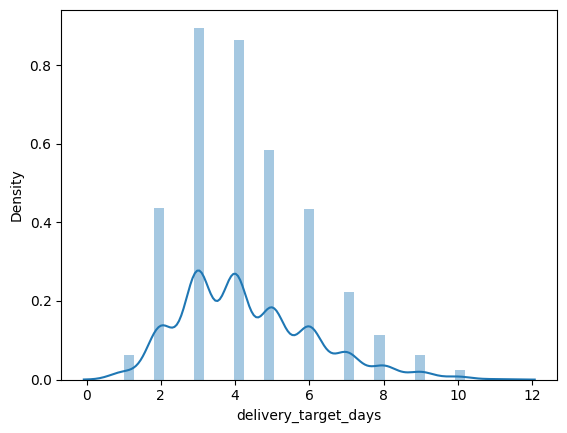

In [ ]:
sns.distplot(df["delivery_target_days"])
plt.show()

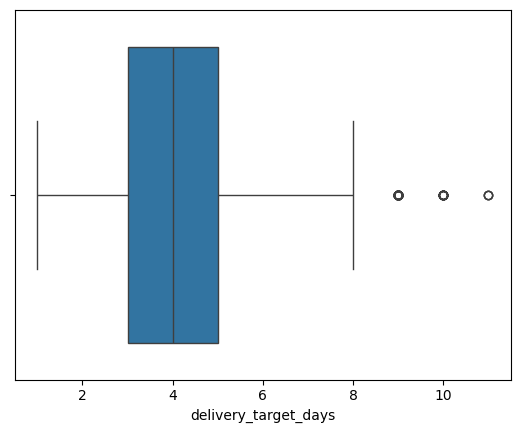

In [ ]:
sns.boxplot(x = df["delivery_target_days"])
plt.show()

In [ ]:
df[df["delivery_target_days"]>8].count()

shipment_id                  74
origin_city                  74
destination_city             74
avg_speed_mph                74
weight_of_truck_tons         74
fuel_price_usd_per_gallon    74
fuel_efficiency_mpg          74
traffic_status               74
road_condition_score         74
weather_condition            74
season                       74
delivery_target_days         74
driver_hours_per_day         74
market_demand_index          74
carrier_type                 74
holiday_indicator            74
lane_type_original           74
lane_type_corrected          74
lane_id_corrected            74
ref_distance_miles           74
ref_speed_limit_mph          74
ref_total_lane_cost_usd      74
fuel_cost_usd                74
total_cost_usd               74
avg_speed_mph_corrected      74
axle_3                       74
axle_4                       74
axle_5                       74
axle_6_plus                  74
dtype: int64

In [ ]:
df_filter = df[df["delivery_target_days"]<=8]
df_filter.shape

(2926, 29)

In [ ]:
df_filter.describe()

,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,road_condition_score,delivery_target_days,driver_hours_per_day,market_demand_index,holiday_indicator,lane_id_corrected,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,avg_speed_mph_corrected,axle_3,axle_4,axle_5,axle_6_plus
count,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.0,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000
mean,57.760219,17.541627,4.008424,5.991955,6.963910,4.171224,8.0,5.033288,0.488722,1.570062,1441.664730,65.700615,2986.071008,1003.200269,3989.271277,57.760219,0.232741,0.255297,0.262816,0.249146
std,10.006606,7.292570,0.578046,1.172812,1.720895,1.598206,0.0,2.868375,0.499958,0.728219,662.249206,7.282193,1495.034558,539.990681,1956.030343,10.006606,0.422651,0.436103,0.440239,0.432592
min,40.000000,5.000000,3.000000,4.000000,4.000000,1.000000,8.0,0.000000,0.000000,1.000000,259.000000,60.000000,470.340000,104.077734,574.417734,40.000000,0.000000,0.000000,0.000000,0.000000
25%,49.525000,11.200000,3.510000,4.960000,5.500000,3.000000,8.0,2.600000,0.000000,1.000000,925.000000,60.000000,1839.210000,605.185769,2500.282906,49.525000,0.000000,0.000000,0.000000,0.000000
50%,57.600000,17.800000,4.005000,6.005000,7.000000,4.000000,8.0,5.050000,0.000000,1.000000,1277.000000,60.000000,2586.290000,878.879449,3502.952415,57.600000,0.000000,0.000000,0.000000,0.000000
75%,66.300000,23.900000,4.520000,7.020000,8.400000,5.000000,8.0,7.500000,1.000000,2.000000,1984.000000,70.000000,3847.790000,1297.080484,5232.100556,66.300000,0.000000,1.000000,1.000000,0.000000
max,75.000000,30.000000,5.000000,8.000000,10.000000,8.000000,8.0,10.000000,1.000000,3.000000,3141.000000,80.000000,8581.210000,3424.456098,11510.796540,75.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_filter["delivery_target_days"].head()


0    2
1    4
2    5
3    4
4    3
Name: delivery_target_days, dtype: int64

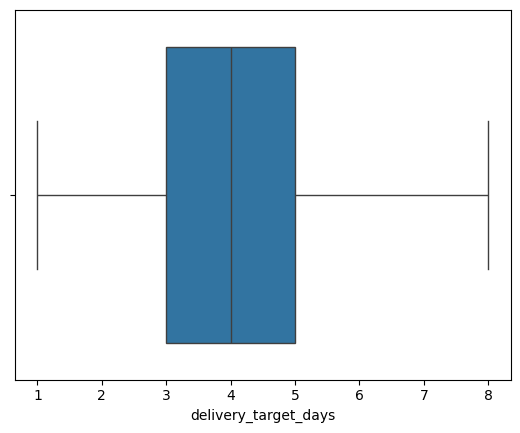

In [ ]:
sns.boxplot(x = df_filter["delivery_target_days"])
plt.show()

C:\Users\aditya.garg\AppData\Local\Temp\ipykernel_9776\2528422829.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_filter["delivery_target_days"])


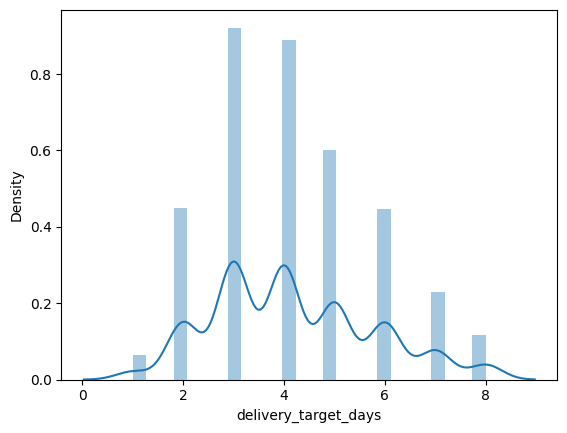

In [ ]:
sns.distplot(df_filter["delivery_target_days"])
plt.show()

In [ ]:

print(df_filter.columns)
df_filter= df_filter.drop(columns=['lane_type_original', 'lane_type_corrected','avg_speed_mph_corrected'],axis=1)

Index(['shipment_id', 'origin_city', 'destination_city', 'avg_speed_mph',
       'weight_of_truck_tons', 'fuel_price_usd_per_gallon',
       'fuel_efficiency_mpg', 'traffic_status', 'road_condition_score',
       'weather_condition', 'season', 'delivery_target_days',
       'driver_hours_per_day', 'market_demand_index', 'carrier_type',
       'holiday_indicator', 'lane_type_original', 'lane_type_corrected',
       'lane_id_corrected', 'ref_distance_miles', 'ref_speed_limit_mph',
       'ref_total_lane_cost_usd', 'fuel_cost_usd', 'total_cost_usd',
       'avg_speed_mph_corrected', 'axle_3', 'axle_4', 'axle_5', 'axle_6_plus'],
      dtype='object')


In [ ]:
df_filter.to_csv("lane_cost_cleaned_final.csv", index=False)
df_filter.head()

,shipment_id,origin_city,destination_city,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,traffic_status,road_condition_score,weather_condition,...,lane_id_corrected,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,axle_3,axle_4,axle_5,axle_6_plus
0,SH_001,"Chicago, IL","Dallas, TX",63.2,12.8,4.04,6.19,Medium,5.1,Rain,...,2,925,70,2007.25,603.715670,2610.965670,1,0,0,0
1,SH_002,"Seattle, WA","Chicago, IL",72.4,23.2,3.65,6.28,Medium,7.1,Clear,...,3,1993,80,5444.88,1158.351911,6603.231911,0,0,0,1
2,SH_003,"Atlanta, GA","Seattle, WA",69.0,13.9,3.56,6.17,Low,4.8,Storm,...,2,2505,70,5398.28,1445.348460,6843.628460,0,0,0,1
3,SH_004,"Phoenix, AZ","Houston, TX",47.0,5.1,4.63,6.83,Low,8.4,Fog,...,1,1166,60,2123.29,790.421669,2913.711669,1,0,0,0
4,SH_005,"Atlanta, GA","Miami, FL",44.1,26.6,4.25,5.32,Low,4.4,Fog,...,1,697,60,1288.06,556.813910,1844.873910,0,1,0,0


In [ ]:
df_filter.columns

Index(['shipment_id', 'origin_city', 'destination_city', 'avg_speed_mph',
       'weight_of_truck_tons', 'fuel_price_usd_per_gallon',
       'fuel_efficiency_mpg', 'traffic_status', 'road_condition_score',
       'weather_condition', 'season', 'delivery_target_days',
       'driver_hours_per_day', 'market_demand_index', 'carrier_type',
       'holiday_indicator', 'lane_id_corrected', 'ref_distance_miles',
       'ref_speed_limit_mph', 'ref_total_lane_cost_usd', 'fuel_cost_usd',
       'total_cost_usd', 'axle_3', 'axle_4', 'axle_5', 'axle_6_plus'],
      dtype='object')

Numeric columns: Index(['avg_speed_mph', 'weight_of_truck_tons', 'fuel_price_usd_per_gallon',
       'fuel_efficiency_mpg', 'road_condition_score', 'delivery_target_days',
       'driver_hours_per_day', 'market_demand_index', 'holiday_indicator',
       'lane_id_corrected', 'ref_distance_miles', 'ref_speed_limit_mph',
       'ref_total_lane_cost_usd', 'fuel_cost_usd', 'total_cost_usd', 'axle_3',
       'axle_4', 'axle_5', 'axle_6_plus'],
      dtype='object')
Correlation matrix:
                            avg_speed_mph  weight_of_truck_tons  \
avg_speed_mph                   1.000000              0.007177   
weight_of_truck_tons            0.007177              1.000000   
fuel_price_usd_per_gallon       0.021654             -0.034036   
fuel_efficiency_mpg             0.017266              0.002575   
road_condition_score           -0.003244             -0.006208   
delivery_target_days           -0.316606             -0.001273   
driver_hours_per_day                 NaN             

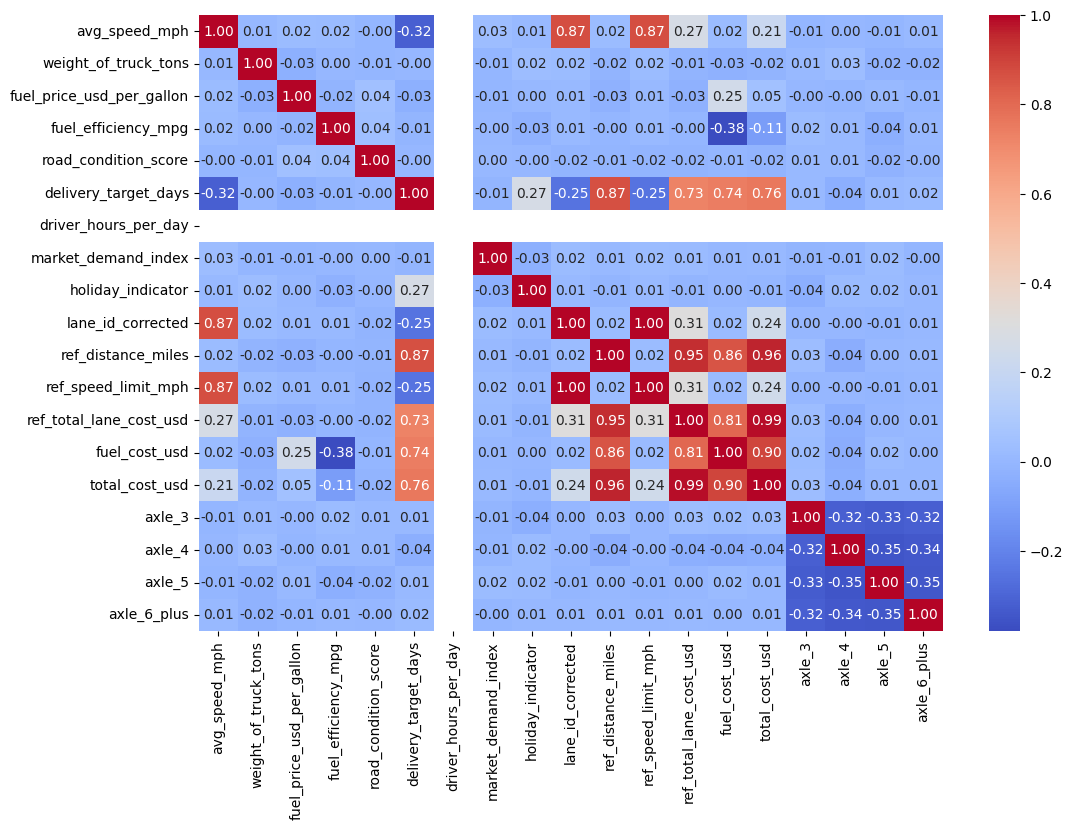

In [ ]:
numeric_cols = df_filter.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:", numeric_cols)

correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix:\n", correlation_matrix)


covariance_matrix = df[numeric_cols].cov()
print("\nCovariance matrix:\n", covariance_matrix)

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [ ]:
df_filter.head(10)

,shipment_id,origin_city,destination_city,avg_speed_mph,weight_of_truck_tons,fuel_price_usd_per_gallon,fuel_efficiency_mpg,traffic_status,road_condition_score,weather_condition,...,lane_id_corrected,ref_distance_miles,ref_speed_limit_mph,ref_total_lane_cost_usd,fuel_cost_usd,total_cost_usd,axle_3,axle_4,axle_5,axle_6_plus
0,SH_001,"Chicago, IL","Dallas, TX",63.2,12.8,4.04,6.19,Medium,5.1,Rain,...,2,925,70,2007.25,603.715670,2610.965670,1,0,0,0
1,SH_002,"Seattle, WA","Chicago, IL",72.4,23.2,3.65,6.28,Medium,7.1,Clear,...,3,1993,80,5444.88,1158.351911,6603.231911,0,0,0,1
2,SH_003,"Atlanta, GA","Seattle, WA",69.0,13.9,3.56,6.17,Low,4.8,Storm,...,2,2505,70,5398.28,1445.348460,6843.628460,0,0,0,1
3,SH_004,"Phoenix, AZ","Houston, TX",47.0,5.1,4.63,6.83,Low,8.4,Fog,...,1,1166,60,2123.29,790.421669,2913.711669,1,0,0,0
4,SH_005,"Atlanta, GA","Miami, FL",44.1,26.6,4.25,5.32,Low,4.4,Fog,...,1,697,60,1288.06,556.813910,1844.873910,0,1,0,0
5,SH_006,"New York, NY","Houston, TX",62.3,27.2,3.94,4.48,High,8.3,Fog,...,2,1630,70,3553.40,1433.526786,4986.926786,0,0,1,0
6,SH_007,"Seattle, WA","Houston, TX",57.3,18.1,3.86,4.10,High,4.6,Snow,...,1,2173,60,3965.72,2045.800000,6011.520000,1,0,0,0
7,SH_008,"Atlanta, GA","Houston, TX",71.8,11.2,3.82,7.02,Low,5.4,Clear,...,3,806,80,2162.50,438.592593,2601.092593,0,1,0,0
8,SH_009,"Miami, FL","Los Angeles, CA",61.9,12.4,3.21,5.83,Medium,5.3,Rain,...,2,2686,70,5882.34,1478.912521,7361.252521,0,0,1,0
10,SH_011,"Dallas, TX","Atlanta, GA",45.8,18.4,3.97,6.77,Medium,5.6,Fog,...,1,828,60,1507.79,485.548006,1993.338006,1,0,0,0


In [ ]:
traffic_order = ['Low', 'Medium', 'High']

ordinal_encoder = OrdinalEncoder(categories=[traffic_order])

df_filter['traffic_status_encoded'] = ordinal_encoder.fit_transform(df_filter[['traffic_status']])
df_filter.drop('traffic_status', axis=1,inplace=True)

In [ ]:
object_cols = df_filter.select_dtypes(include='object').columns
print(object_cols)

Index(['shipment_id', 'origin_city', 'destination_city', 'weather_condition',
       'season', 'carrier_type'],
      dtype='object')


In [ ]:
df_encoded = pd.get_dummies(df_filter,columns=object_cols,drop_first=True)
df_encoded.columns


Index(['avg_speed_mph', 'weight_of_truck_tons', 'fuel_price_usd_per_gallon',
       'fuel_efficiency_mpg', 'road_condition_score', 'delivery_target_days',
       'driver_hours_per_day', 'market_demand_index', 'holiday_indicator',
       'lane_id_corrected',
       ...
       'weather_condition_Fog', 'weather_condition_Rain',
       'weather_condition_Snow', 'weather_condition_Storm', 'season_Spring',
       'season_Summer', 'season_Winter', 'carrier_type_Flatbed',
       'carrier_type_Refrigerated', 'carrier_type_Tanker'],
      dtype='object', length=2973)

In [ ]:
df_encoded["traffic_status_encoded"].head(10)

0     1.0
1     1.0
2     0.0
3     0.0
4     0.0
5     2.0
6     2.0
7     0.0
8     1.0
10    1.0
Name: traffic_status_encoded, dtype: float64

In [ ]:
X = df_encoded.drop(columns=['total_cost_usd','lane_id_corrected','avg_speed_mph'])
y_cost = df_encoded['total_cost_usd']
y_lane = df_encoded['lane_id_corrected'] 
y_speed = df_encoded['avg_speed_mph']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# After creating X and before training
columns_used = X.columns



# Save it using joblib (just once)
import joblib
joblib.dump(columns_used, 'columns_used.pkl')

X_train_cost, X_test_cost, y_train_cost, y_test_cost = train_test_split(
    X, y_cost, test_size=0.2, random_state=42
)

# Classification split
X_train_lane, X_test_lane, y_train_lane, y_test_lane = train_test_split(
    X, y_lane, test_size=0.2, random_state=42
)

#for speed 
X_train_speed, X_test_speed, y_train_speed, y_test_speed = train_test_split(
    X, y_speed, test_size=0.2, random_state=42
)

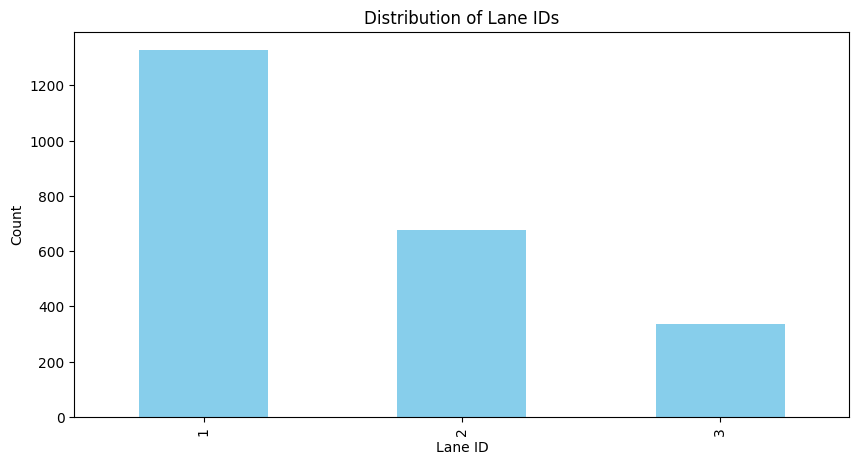

In [ ]:
plt.figure(figsize=(10,5))
y_train_lane.value_counts().plot(kind='bar', color='skyblue')
plt.xlabel("Lane ID")
plt.ylabel("Count")
plt.title("Distribution of Lane IDs")
plt.show()

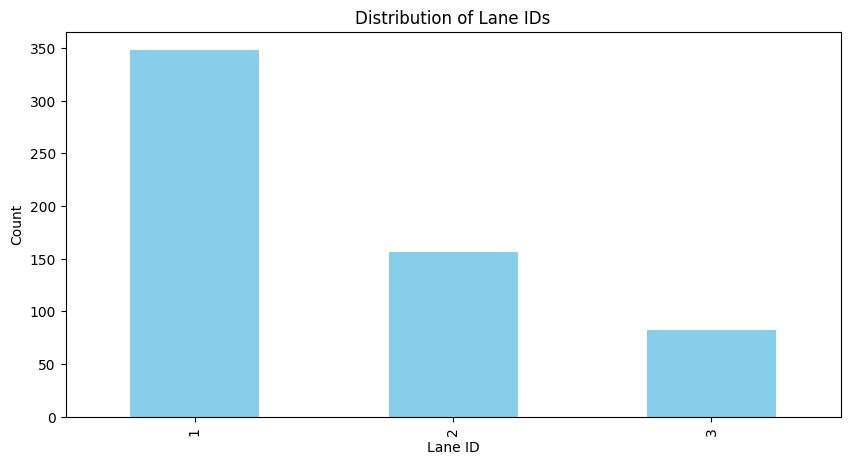

In [ ]:

plt.figure(figsize=(10,5))
y_test_lane.value_counts().plot(kind='bar', color='skyblue')
plt.xlabel("Lane ID")
plt.ylabel("Count")
plt.title("Distribution of Lane IDs")
plt.show()

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    # "Random Forest": RandomForestRegressor(),
    
}

results = []

for name, model in models.items():
    model.fit(X_train_cost, y_train_cost)
    y_pred = model.predict(X_test_cost)
    
    r2 = r2_score(y_test_cost, y_pred)
    mae = mean_absolute_error(y_test_cost, y_pred)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae
    })
    print(f"{name} -> \n R2: {r2:.4f}, \n MAE: {mae:.6f}") 

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\nModel Performance Comparison:")
print(results_df)

rf_speed = RandomForestRegressor(n_estimators=200, random_state=42)
rf_speed.fit(X_train_speed, y_train_speed)

y_pred_speed = rf_speed.predict(X_test_speed)
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test_speed, y_pred_speed)
mae = mean_absolute_error(y_test_speed, y_pred_speed)
print("\nRandom Forest->")
print(f"R2: {r2:.4f}" )
print(f"MAE: {mae:.6f}")


Random Forest -> 
 R2: 0.9991, 
 MAE: 34.001979

Model Performance Comparison:
           Model  R2 Score        MAE
0  Random Forest  0.999077  34.001979

Random Forest->
R2: 0.8706
MAE: 2.868704


In [ ]:
models = {
  
    "Random Forest": RandomForestClassifier(),
   
    # "KNN": KNeighborsClassifier(),
    
}

results = []

for name, model in models.items():
    model.fit(X_train_lane, y_train_lane)
    y_pred = model.predict(X_test_lane)
    
    acc = accuracy_score(y_test_lane, y_pred)
    prec = precision_score(y_test_lane, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_lane, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_lane, y_pred, average='weighted', zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    print(f"{name} -> \nAccuracy={acc:.4f}, \nPrecision={prec:.4f}, \nRecall={rec:.4f}, \nF1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\nModel Performance Comparison:")
print(results_df)

Random Forest -> 
Accuracy=0.9693, 
Precision=0.9725, 
Recall=0.9693, 
F1=0.9682

Model Performance Comparison:
           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.969283   0.972461  0.969283  0.968228


In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_cost, y_train_cost)
y_pred_reg = rf.predict(X_test_cost)

r2 = r2_score(y_test_cost, y_pred_reg)
mae = mean_absolute_error(y_test_cost, y_pred_reg)

print("\n🌲 Random Forest Regressor Results:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_lane, y_train_lane)
y_pred_class = knn.predict(X_test_lane)

acc = accuracy_score(y_test_lane, y_pred_class)
f1 = f1_score(y_test_lane, y_pred_class, average='weighted')

print("\n🤖 KNN Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")

rf_speed = RandomForestRegressor(n_estimators=200, random_state=42)
rf_speed.fit(X_train_speed, y_train_speed)

y_pred_speed = rf_speed.predict(X_test_speed)
from sklearn.metrics import r2_score, mean_absolute_error
print("\n🤖 Random Forest Regressor Results:")
print("Avg Speed R2:", r2_score(y_test_speed, y_pred_speed))
print("Avg Speed MAE:", mean_absolute_error(y_test_speed, y_pred_speed))


🌲 Random Forest Regressor Results:
R² Score: 0.9990
Mean Absolute Error: 33.43

🤖 KNN Classifier Results:
Accuracy: 0.9949
F1-Score: 0.9949

🤖 Random Forest Regressor Results:
Avg Speed R2: 0.8705592105616836
Avg Speed MAE: 2.868703924914674


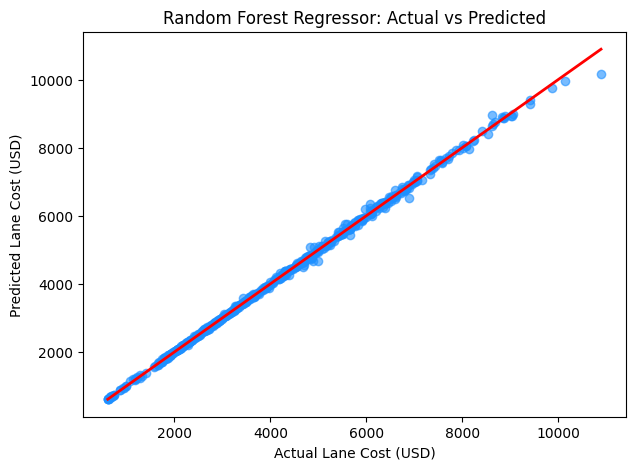

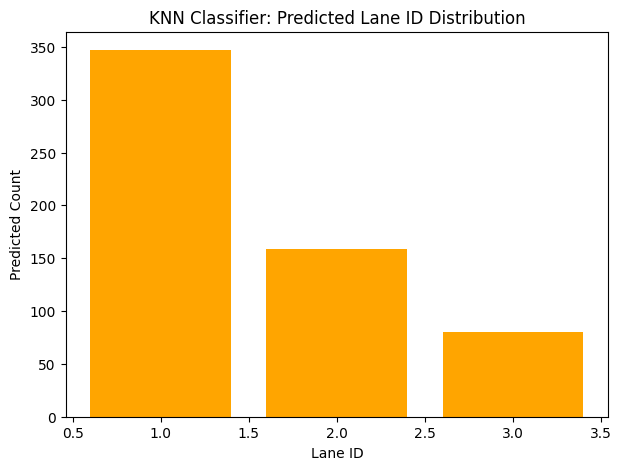

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_cost, y_pred_reg, color='dodgerblue', alpha=0.6)
plt.plot([y_test_cost.min(), y_test_cost.max()],
         [y_test_cost.min(), y_test_cost.max()],
         color='red', linewidth=2)
plt.xlabel("Actual Lane Cost (USD)")
plt.ylabel("Predicted Lane Cost (USD)")
plt.title("Random Forest Regressor: Actual vs Predicted")
plt.show()

# Classification performance
plt.figure(figsize=(7,5))
unique, counts = np.unique((y_pred_class), return_counts=True)
plt.bar(unique, counts, color='orange')
plt.title("KNN Classifier: Predicted Lane ID Distribution")
plt.xlabel("Lane ID")
plt.ylabel("Predicted Count")
plt.show()


In [ ]:
import requests

# -------------------------------
# 🔑 Replace with your TomTom API Key
# -------------------------------
TOMTOM_API_KEY = "YOur key"

# -------------------------------
# 📍 Example location (Amsterdam)
# -------------------------------
lat, lon = 32.7779765, -96.7962148

# -------------------------------
# 🌐 TomTom Traffic Flow API endpoint
# -------------------------------
url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/relative0/10/json"
params = {
    "point": f"{lat},{lon}",
    "unit": "KMPH",
    "openLr": "false",
    "key": TOMTOM_API_KEY
}

# -------------------------------
# 📡 Send request
# -------------------------------
response = requests.get(url, params=params)

# -------------------------------
# 🧾 Check response
# -------------------------------
if response.status_code == 200 and response.text.strip():
    try:
        data = response.json()
        print("✅ API working successfully!\n")
        print("📊 Sample Traffic Data:")
        print(f"Current Speed: {data['flowSegmentData']['currentSpeed']} km/h")
        print(f"Free Flow Speed: {data['flowSegmentData']['freeFlowSpeed']} km/h")
        print(f"Confidence: {data['flowSegmentData']['confidence']}")
        print(f"Road Closure: {data['flowSegmentData']['roadClosure']}")
    except Exception as e:
        print("⚠️ JSON Parse Error:", e)
        print(response.text)
else:
    print("❌ API request failed!")
    print("Status Code:", response.status_code)
    print("Response:", response.text)


❌ API request failed!
Status Code: 403
Response: {"detailedError":{"code":"Forbidden","message":"You are not allowed to access this endpoint"}}


In [ ]:
def get_coordinates(city_name):
    """
    Get latitude and longitude for a given city using TomTom Geocoding API.
    """
    url = f"https://api.tomtom.com/search/2/geocode/{city_name}.json"
    params = {
        "storeResult": "false",
        "view": "Unified",
        "limit": 1,
        "key": "api key "
    }

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        if "results" in data and len(data["results"]) > 0:
            position = data["results"][0]["position"]
            lat = position["lat"]
            lon = position["lon"]
            return lat, lon
        else:
            print(f"⚠️ No coordinates found for {city_name}")
            return None, None
    except Exception as e:
        print(f"❌ Error getting coordinates for {city_name}: {e}")
        return None, None
print(get_coordinates("Dallas, TX"))

❌ Error getting coordinates for Dallas, TX: 403 Client Error: Forbidden for url: https://api.tomtom.com/search/2/geocode/Dallas,%20TX.json?storeResult=false&view=Unified&limit=1&key=api+key+
(None, None)


In [ ]:
import requests

EIA_API_KEY = "OQdfxEcYk9VyPNOoNjHkymVqMK0stggKOtRcHPCn"

# -------------------------------
# 🌐 EIA API v2 endpoint for gasoline price
# -------------------------------
url = f"https://api.eia.gov/v2/petroleum/pri/gnd/data/"
params = {
    "frequency": "weekly",
    "data[0]": "value",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 1,  # only latest data point
    "api_key": EIA_API_KEY
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    
    # Extract latest price
    latest_price = data["response"]["data"][0]["value"]
    print("✅ Latest Gasoline Price (USD/gal):", latest_price)
except Exception as e:
    print("❌ Error fetching fuel price:", e)


✅ Latest Gasoline Price (USD/gal): 3.073


TOMTOM_API_KEY = "VoMgKXVjYZAnjRwKmU8C9OxkykqSWeAM"
EIA_API_KEY = "OQdfxEcYk9VyPNOoNjHkymVqMK0stggKOtRcHPCn"

In [ ]:
import pandas as pd
import numpy as np
import random
import requests
import time

# -------------------------------
# 🧩 Load cities dataset
# -------------------------------
cities_df = pd.read_csv("standard_us_city_lanes_with_speed1(in).csv")
cities_df.columns = cities_df.columns.str.strip()

# ✅ Ensure shipment_id column exists
if 'shipment_id' not in cities_df.columns:
    cities_df.insert(0, 'shipment_id', [f"SH_{i:03}" for i in range(1, len(cities_df) + 1)])

# -------------------------------
# ⚙️ Constants
# -------------------------------
weight_of_truck_tons = 12.8
fuel_efficiency_mpg = 6.19
hours_per_day = 8

# -------------------------------
# 🧩 Mappings
# -------------------------------
lane_type_map = {'slow': 1, 'normal': 2, 'fast': 3}
lane_type_str_map = {1: 'slow', 2: 'normal', 3: 'fast'}
weather_speed_reduction = {'Clear': 0, 'Fog': 2, 'Rain': 3, 'Snow': 4, 'Storm': 5}
axle_cost_addition = {3: 0, 4: 5.73, 5: 13.71, 6: 19.42}

coordinate_cache = {}

# -------------------------------
# 🚗 Traffic penalty
# -------------------------------
def traffic_speed_penalty(traffic_index):
    if traffic_index <= 3:
        return 0
    elif 4 <= traffic_index <= 6:
        return 2
    elif 7 <= traffic_index <= 8:
        return 4
    else:
        return 6

# -------------------------------
# 🌐 TomTom Geocoding
# -------------------------------
def get_coordinates(city_name, tomtom_api_key):
    if city_name in coordinate_cache:
        return coordinate_cache[city_name]
    url = f"https://api.tomtom.com/search/2/geocode/{city_name}.json"
    params = {"storeResult": "false", "view": "Unified", "limit": 1, "key": tomtom_api_key}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        if "results" in data and len(data["results"]) > 0:
            pos = data["results"][0]["position"]
            coordinate_cache[city_name] = (pos["lat"], pos["lon"])
            return pos["lat"], pos["lon"]
    except:
        pass
    print(f"⚠️ Could not fetch coordinates for {city_name}")
    return None, None

# -------------------------------
# 🌤️ Open-Meteo Weather
# -------------------------------
def get_weather_condition(city_name, tomtom_api_key):
    lat, lon = get_coordinates(city_name, tomtom_api_key)
    if lat is None or lon is None:
        return "Unknown"
    url = "https://api.open-meteo.com/v1/forecast"
    params = {"latitude": lat, "longitude": lon, "current_weather": True}
    try:
        response = requests.get(url, params=params)
        data = response.json()
        code = data["current_weather"]["weathercode"]
        if code in [71, 73, 75, 77]:
            return "Snow"
        elif code in [95, 96, 99]:
            return "Storm"
        elif code in [61, 63, 65, 80, 81, 82]:
            return "Rain"
        elif code in [45, 48]:
            return "Fog"
        else:
            return "Clear"
    except:
        return "Unknown"

# -------------------------------
# 🚦 TomTom Traffic Flow
# -------------------------------
def get_traffic_index(city_name, tomtom_api_key):
    lat, lon = get_coordinates(city_name, tomtom_api_key)
    if lat is None or lon is None:
        return 5
    url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/relative0/10/json"
    params = {"point": f"{lat},{lon}", "unit": "MPH", "key": tomtom_api_key}
    try:
        response = requests.get(url, params=params)
        data = response.json().get("flowSegmentData", {})
        current_speed = data.get("currentSpeed")
        free_speed = data.get("freeFlowSpeed")
        if current_speed and free_speed:
            ratio = free_speed / max(current_speed, 1)
            return min(10, max(1, round(ratio * 5)))
    except:
        pass
    return 5

# -------------------------------
# ⛽ Dynamic Fuel Price (EIA)
# -------------------------------
def get_latest_fuel_price(eia_api_key):
    url = "https://api.eia.gov/v2/petroleum/pri/gnd/data/"
    params = {
        "frequency": "weekly",
        "data[0]": "value",
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "length": 1,
        "api_key": eia_api_key
    }
    try:
        response = requests.get(url, params=params)
        data = response.json()
        return float(data["response"]["data"][0]["value"])
    except:
        print("⚠️ Could not fetch live fuel data, using default $4.04")
        return 4.04

# -------------------------------
# 🧠 Real-Time Recommendation
# -------------------------------
def recommend_best_lane_by_shipment(shipment_id, tomtom_api_key, eia_api_key):
    shipment = df_filter[df_filter['shipment_id'] == shipment_id]
    if shipment.empty:
        print("❌ Invalid Shipment ID.")
        return None

    origin = shipment.iloc[0]['origin_city']
    destination = shipment.iloc[0]['destination_city']
    target_days = shipment.iloc[0].get('delivery_target_days', 1.5)  # default if not in dataset

    print(f"\n🔍 Shipment {shipment_id} details fetched from dataset:")
    print(f"  Origin: {origin}")
    print(f"  Destination: {destination}")
    print(f"  Target Days: {target_days}\n")

    return recommend_best_lane_user(origin, destination, target_days, tomtom_api_key, eia_api_key)

# -------------------------------
# 🚛 Core Function (Reused)
# -------------------------------
def recommend_best_lane_user(origin, destination, target_days, tomtom_api_key, eia_api_key, axle_count=None):
    df = cities_df[(cities_df['origin_city'] == origin) & (cities_df['dest_city'] == destination)]
    if df.empty:
        print("⚠️ No data for this route.")
        return None

    distance = df.iloc[0]['distance_miles_est']
    required_speed = distance / (target_days * hours_per_day)

    weather = get_weather_condition(origin, tomtom_api_key)
    traffic = get_traffic_index(origin, tomtom_api_key)
    fuel_price = get_latest_fuel_price(eia_api_key)

    weather_penalty = weather_speed_reduction.get(weather, 0)
    traffic_penalty = traffic_speed_penalty(traffic)
    adjusted_speed = max(30, required_speed - (weather_penalty + traffic_penalty))

    if adjusted_speed > 80:
        print("⚠️ Impossible to deliver under current conditions.")
        return None

    lane_type = 1 if adjusted_speed < 60 else (2 if adjusted_speed < 70 else 3)
    selected_lane = lane_type_str_map[lane_type]

    row = df[df['lane_type'].str.lower() == selected_lane].iloc[0]
    base_cost = row['total_cost_usd']
    lane_speed_limit = row['speed_limit_mph']

    fuel_cost = (distance / fuel_efficiency_mpg) * fuel_price
    total_cost = base_cost + fuel_cost + axle_cost_addition.get(axle_count or 4, 0)

    # Smart suggestions
    suggestions = []
    if weather in ['Rain', 'Snow', 'Storm']:
        suggestions.append("⚠️ Poor weather — prefer slower lanes for safety.")
    if traffic >= 8:
        suggestions.append("🚦 Heavy traffic — reroute or delay start to off-peak hours.")
    if fuel_price > 4.5:
        suggestions.append("⛽ High fuel prices — try optimizing load or combining deliveries.")

    print(f"🚚 Real-Time Lane Recommendation")
    print(f"-------------------------------------")
    print(f"Route: {origin} → {destination}")
    print(f"Weather: {weather}")
    print(f"Traffic Index: {traffic}/10")
    print(f"Required Speed: {round(required_speed,2)} mph")
    print(f"Adjusted Speed: {round(adjusted_speed,2)} mph")
    print(f"Selected Lane: {selected_lane.capitalize()}")
    print(f"Fuel Price: ${fuel_price}/gal")
    print(f"Fuel Cost: ${round(fuel_cost,2)}")
    print(f"Total Cost: ${round(total_cost,2)}")

    if suggestions:
        print("\n🧭 Smart Suggestions:")
        for s in suggestions:
            print("  -", s)
    else:
        print("\n✅ Conditions are optimal for travel.")

    return {
        "lane_type": selected_lane,
        "total_cost": round(total_cost, 2),
        "fuel_price": round(fuel_price, 2),
        "weather": weather,
        "traffic_index": traffic,
        "suggestions": suggestions
    }

# -------------------------------
# 🧾 Example: Fetch by Shipment ID
# -------------------------------
TOMTOM_API_KEY = "VoMgKXVjYZAnjRwKmU8C9OxkykqSWeAM"
EIA_API_KEY = "OQdfxEcYk9VyPNOoNjHkymVqMK0stggKOtRcHPCn"

best = recommend_best_lane_by_shipment("SH_001", TOMTOM_API_KEY, EIA_API_KEY)



🔍 Shipment SH_001 details fetched from dataset:
  Origin: Chicago, IL
  Destination: Dallas, TX
  Target Days: 2

🚚 Real-Time Lane Recommendation
-------------------------------------
Route: Chicago, IL → Dallas, TX
Weather: Clear
Traffic Index: 5/10
Required Speed: 57.81 mph
Adjusted Speed: 55.81 mph
Selected Lane: Slow
Fuel Price: $3.886/gal
Fuel Cost: $580.7
Total Cost: $2291.2

✅ Conditions are optimal for travel.


TOMTOM_API_KEY = "VoMgKXVjYZAnjRwKmU8C9OxkykqSWeAM"
EIA_API_KEY = "OQdfxEcYk9VyPNOoNjHkymVqMK0stggKOtRcHPCn"
